# Импорт библиотек

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import fsolve

# Задание 1

### Отделите корни заданного уравнения графическим методом.

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_29628\1840389110.py:2: RuntimeWarning: divide by zero encountered in log
  return np.log(x + 6.1)


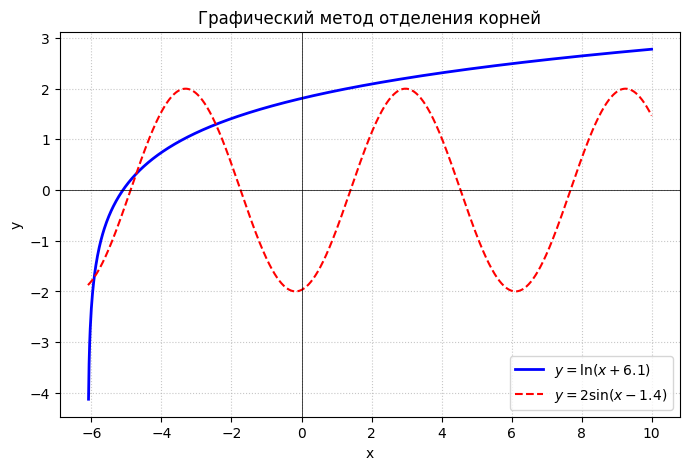

In [25]:
def f1(x):
    return np.log(x + 6.1)

def f2(x):
    return 2 * np.sin(x - 1.4)


# Функция разности (корень там, где f_diff == 0)
def f_diff(x):
    return f1(x) - f2(x)


# Диапазон x (с учетом области определения ln: x > -6.1)
x_plot = np.linspace(-6.1, 10, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, f1(x_plot), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x_plot, f2(x_plot), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')


# Оформление
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

На графике видно, что корни находятся в районах по оси х: -5 и -2. Я использую библиотеку SciPy для вывода корней.

C:\Users\a1v2f5\AppData\Local\Temp\ipykernel_29628\1840389110.py:2: RuntimeWarning: divide by zero encountered in log
  return np.log(x + 6.1)


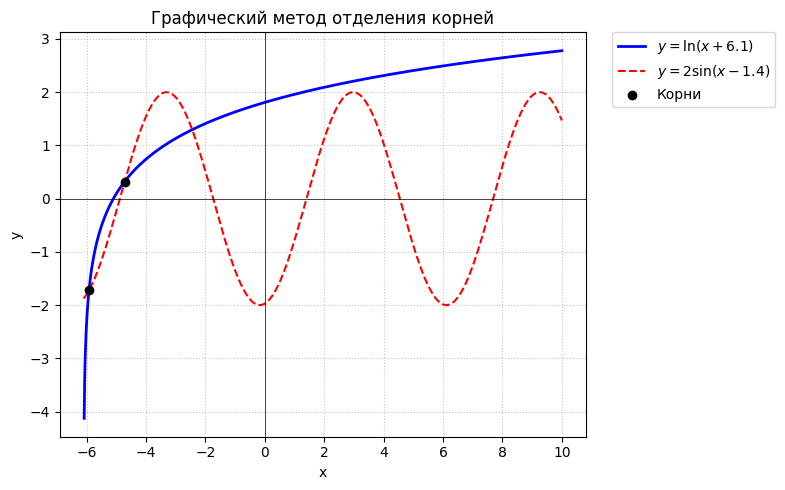

Найденные корни уравнения ln(x + 6.1) = 2*sin(x - 1.4): 
x1 ≈ -5.921
x2 ≈ -4.722


In [26]:
# Визуально корни находятся в районах: -6, -5
initial_guesses = [-6, -5]
roots = fsolve(f_diff, initial_guesses)
unique_roots = np.unique(np.round(roots, 5)) # На всякий случай, если вдруг появятся дубликаты во время расчётов.


x_plot = np.linspace(-6.1, 10, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_plot, f1(x_plot), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x_plot, f2(x_plot), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')


# Отметим корни на графике точками
plt.scatter(unique_roots, f1(unique_roots), color='black', zorder=5, label='Корни')


# Оформление
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


# Печать результата
print("Найденные корни уравнения ln(x + 6.1) = 2*sin(x - 1.4): ")
for i, root in enumerate(unique_roots, 1):
    print(f"x{i} ≈ {root:.3f}")


Программа вычислила два корня с использованием инструментального пакета Scipy.

# Задание 2

In [27]:
# Определяем функцию f(x) = ln(x + 6.1) - 2*sin(x - 1.4)
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def bisection_method(a, b, eps):

    # Проверка условия теоремы Больцано-Коши
    if f(a) * f(b) > 0:
        print("На данном отрезке корней нет или их четное количество")
        return None

    while (b - a) / 2 > eps:
        
        mid = (a + b) / 2

        # Выбираем половину отрезка, на которой функция меняет знак
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid

    return (a + b) / 2

# Исходя из графического анализа, корень лежит в интервале [-6, -5]
a, b = -6, -5
epsilon = 1e-3

root = bisection_method(a, b, epsilon)

if root is not None:
    print(f"Корень уравнения: {root:.3f}")

Корень уравнения: -5.921


Корень совпадает с первым корнем из первого задания.

# Задание 3

In [12]:
def phi(x):

    # Преобразованная функция x = exp(2*sin(x - 1.4)) - 6.1
    return np.exp(2 * np.sin(x - 1.4)) - 6.1

def simple_iteration(x0, eps):
    x_old = x0
    x_new = phi(x_old)
    iterations = 1

    # Итерируем, пока разность соседних приближений больше eps
    while abs(x_new - x_old) > eps:
        x_old = x_new
        x_new = phi(x_old)
        iterations += 1

    return x_new, iterations

# Параметры
x_start = -6.0  
precision = 1e-6

root, nit = simple_iteration(x_start, precision)

print(f"Корень уравнения: {root:.6f}")
print(f"Количество итераций: {nit}")

Корень уравнения: -5.921485
Количество итераций: 8


Спустя 8 итераций программа вывела почти тот же корень (если округлить до тысячных, то разница с прошлым результатом составит 0.001)

# Задание 4 

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя комбинированный метод хорд и касательных.

In [ ]:
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def df(x):
    return 1 / (x + 6.1) - 2 * np.cos(x - 1.4)

def df2(x):
    return -1 / (x + 6.1)**2 + 2 * np.sin(x - 1.4)


def solve_combined(a, b, eps):
    x_n = a # Для метода хорд
    x_k = b # Для метода касательных
    
    # для метода касательных беру край, где f(x)*f''(x) > 0
    if f(a) * df2(a) < 0:
        x_n, x_k = b, a
    
    while abs(x_n - x_k) > eps:

        # Формула хорд
        x_n = x_n - (f(x_n) * (x_k - x_n)) / (f(x_k) - f(x_n))
        
        # Формула касательных
        x_k = x_k - f(x_k) / df(x_k)
        
    root = (x_n + x_k) / 2
    print(f"Корень: {root:.6f}")

a = -6.0
b = -5.0
eps = 1e-6

solve_combined(a, b, eps)


Корень: -4.722275


После применения этого метода был выведен второй корень.

# Задание 5

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя одиниз инструментальных пакетов.

In [31]:
# 1. Определяем переменную и уравнение
x = sp.Symbol('x')
f1 = sp.log(x + 6.1)
f2 = 2 * sp.sin(x - 1.4)
equation = f1 - f2

# 2. Находим корень численно (nsolve)
# Передаем: уравнение, переменную и начальную точку поиска
# Так как поиск от -6 до -5, возьмем среднее -5.5 или любую точку рядом
root = sp.nsolve(equation, x, -5.5)

print(f"Найденный корень: {root:.3f}")




Найденный корень: -4.722


Ответ от инструментального пакета Scipy вывел ответ равный результату в задании 3.